tensor(2.3500)


<Axes: ylabel='Count'>

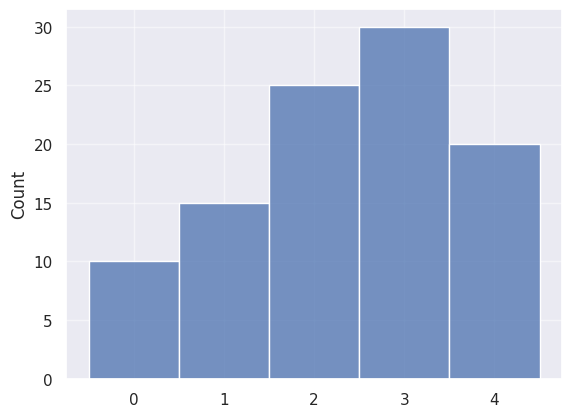

In [1]:
import torch
from simulator import GenerativeProcess, BinomialMixtureSimulator
import seaborn as sns
from utils.statistics import calculate_frequency

sns.set_theme(style="darkgrid")

torch.manual_seed(1)
x_obs = GenerativeProcess(0.7, 0.2, 0.8).mixture.sample((100,))
s_obs = x_obs.mean()
print(s_obs)
sns.histplot(x_obs, discrete=True)

In [2]:
from sampler.base_abc import BaseABC

simulator = BinomialMixtureSimulator()

algo = BaseABC(
    observations=x_obs,
    simulator=simulator,
    summary_statistic="frequency",
    threshold=0.1,
)

n_sim = 15
accepted = algo.compute(n_sim)
print(f"Acceptance ratio: {len(accepted) / n_sim * 100:.2f}%")

Acceptance ratio: 13.33%


<Axes: ylabel='Count'>

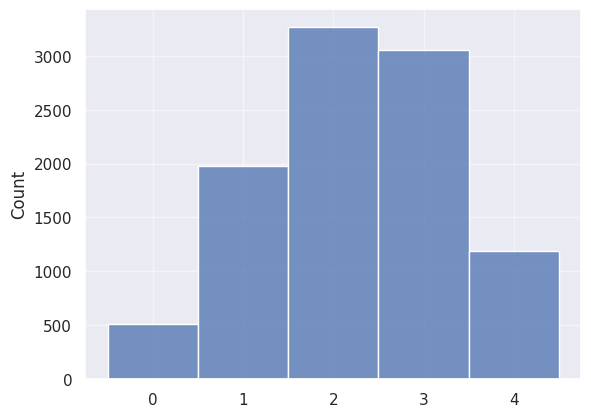

In [3]:
new_samples = simulator.generate(*accepted[0], times=10000)
sns.histplot(new_samples, discrete=True)

In [4]:
simulator = BinomialMixtureSimulator()

t1, t2, r = simulator.propose_parameters(1)
x_sim = simulator.generate(t1, t2, r, times=100)
s_sim = x_sim.mean()
dis_ar = torch.norm(s_sim - s_obs)

dis_ar

tensor(0.7300)

In [5]:
from torch.distributions import Binomial, Uniform

p_theta = (
    Binomial(total_count=4, probs=torch.tensor([[0.9], [0.6], [0.5]]))
    .log_prob(torch.arange(0, 5, 1))
    .exp()
)
p_theta

tensor([[1.0000e-04, 3.6000e-03, 4.8600e-02, 2.9160e-01, 6.5610e-01],
        [2.5600e-02, 1.5360e-01, 3.4560e-01, 3.4560e-01, 1.2960e-01],
        [6.2500e-02, 2.5000e-01, 3.7500e-01, 2.5000e-01, 6.2500e-02]])

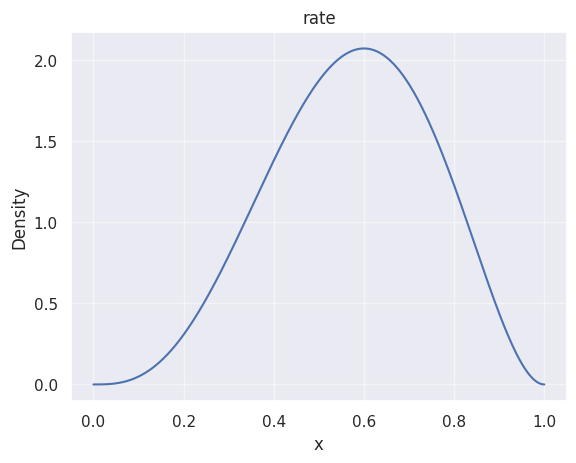

In [6]:
from torch.distributions import Beta
import matplotlib.pyplot as plt

rate = Beta(4, 3)
x = torch.linspace(0, 1, 1000)
y = torch.exp(rate.log_prob(x))

plt.plot(x.numpy(), y.numpy())
plt.title("rate")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

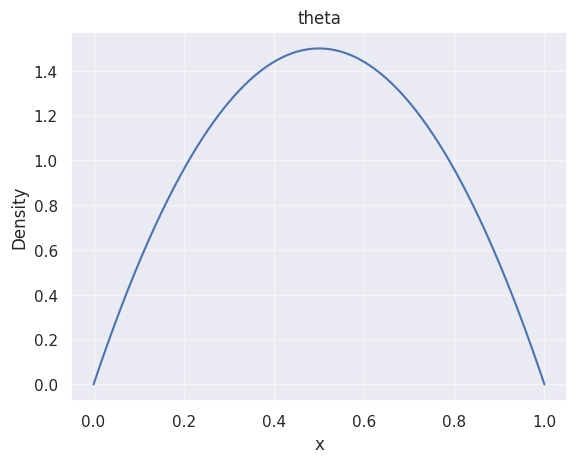

In [7]:
theta = Beta(2, 2)
x_theta1 = torch.linspace(0, 1, 1000)
y_theta1 = torch.exp(theta.log_prob(x_theta1))

plt.plot(x_theta1.numpy(), y_theta1.numpy())
plt.title("theta")
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

In [8]:
samples_rate = rate.sample((100,))
samples_theta1 = theta.sample((100,))
samples_theta2 = theta.sample((100,)) * samples_theta1

In [9]:
importance_weights = []
for _theta1, _theta2, _rate in zip(samples_theta1, samples_theta2, samples_rate):
    sim = simulator.generate(
        theta1=_theta1, theta2=_theta2, rate=_rate, times=x_obs.size(0)
    )

    obs_v, obs_p = calculate_frequency(x_obs, min_length=0)
    _, sim_p = calculate_frequency(sim, min_length=obs_v.size(0))

    prior_weights = (
        Uniform(0, 1).log_prob(_rate)
        * Uniform(0, 1).log_prob(_theta1)
        * Uniform(0, 1).log_prob(_theta2)
    )
    proposal_weights = (
        rate.log_prob(_rate) * theta.log_prob(_theta1) * theta.log_prob(_theta2)
    )

    weight = (prior_weights - proposal_weights).exp()

    distance = (obs_p - sim_p).abs().sum()
    kernel = torch.exp(-distance / 0.1)
    importance_weights.append(kernel * weight)

normalized_weights = torch.stack(importance_weights)
normalized_weights = normalized_weights / normalized_weights.sum()
normalized_weights.size()

expected_rate = (samples_rate * normalized_weights).sum()
expected_theta1 = (samples_theta1 * normalized_weights).sum()
expected_theta2 = (samples_theta2 * normalized_weights).sum()

print(f"Rate: {expected_rate}\nTheta1: {expected_theta1}\nTheta2: {expected_theta2}\n")

Rate: 0.622826099395752
Theta1: 0.7104933857917786
Theta2: 0.3138764798641205



<Axes: ylabel='Count'>

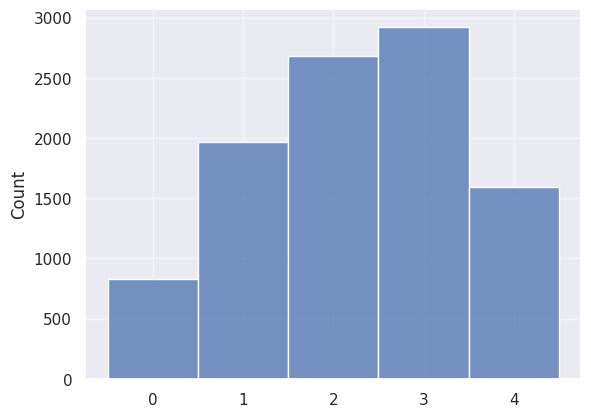

In [10]:
is_samples = simulator.generate(
    expected_theta1, expected_theta2, expected_rate, times=10000
)
sns.histplot(is_samples, discrete=True)